In [29]:
import os
import json
import pandas as pd

results_dir = "../../results/synth/"
trails = 2
seeds = ["test"+str(i) for i in range(trails)]
algorithms = ["MALIBO", "PFNs4BO-EI", "pPFNs4BO-pca-ei" , "metaPFNs4BO-joint-batched-context-mean-weights"]#,] #, "metaPFNs4BO-mean-weights", "pPFNs4BO-pca-ei", "metaPFNs4BO-joint-batched-context-mean-weights", "metaPFNs4BO-joint-batched-context", "metaPFNs4BO-error-model-mean-weights", "metaPFNs4BO-error-model"]#, ]#, "metaPFNs4BO",  , "pPFNs4BO-pca-ei", "metaPFNs4BO-joint-batched-context-mean-weights"]#, "pPFNs4BO-band"]#, , "pPFNs4BO"]
spaces = ["hartmann3d_synth"]
task_list_per_space = {
    "hartmann3d_synth": ["0"]
}
time_horizon  = 50


In [30]:
results = {}
for algo in algorithms:
    results[algo] = {}
    for space in spaces:
        results[algo][space] = {}
        for task in task_list_per_space[space]:
            results[algo][space][task] = {}
            for seed in seeds:
                csv_path = os.path.join(results_dir, seed, algo, space, task +".csv")
                df = pd.read_csv(csv_path)
                results[algo][space][task][seed]=  df.regret.values.tolist()



In [31]:
import matplotlib.pyplot as plt
import json
import numpy as np
import pandas as pd
# from cd_diagram import draw_cd_diagram as draw
from matplotlib.ticker import MaxNLocator

class BenchmarkPlotter:
    def __init__(self, experiments, seeds, results, spaces, task_list_per_space, time_horizon):
        
        super(BenchmarkPlotter, self).__init__()
        self.experiments = experiments
        self.seeds = seeds if seeds is not None else ["test0", "test1", "test2", "test3", "test4"]
        self.results = results
        self.search_spaces = spaces
        self.task_list_per_space = task_list_per_space
        self.n_trials = time_horizon
        self.name = "synth_1d_benchmark"
        self.draw_std = True
        self.draw_per_space = False

    def plot(self):
        self.generate_rank_and_regret()
        if self.draw_per_space:
            self.generate_plots_per_search_space( name= self.name+"_per_space")
        self.generate_aggregated_plots(name= self.name+"_aggregated")

    def make_rank_and_regret_plot(self, rank_list, regret_list, axis_rank, axis_regret, title=""):

        rank = np.array(rank_list)
        regret = np.array(regret_list)
        sample_size, n_experiments, n_bo_iters = rank.shape

        rank_mean = np.nanmean(rank,axis=0)
        regret_mean = np.nanmean(regret,axis=0)
        rank_std = np.nanstd(rank,axis=0)
        regret_std = np.nanstd(regret,axis=0)
        ci_factor = 1.96/np.sqrt(sample_size)

        self.plots_on_axis(axis_rank, rank_mean, rank_std, ci_factor, title, "Average Rank", self.draw_std)
        self.plots_on_axis(axis_regret, regret_mean, regret_std, ci_factor, title, "Average Regret",  self.draw_std, scale="log")


    def plots_on_axis(self, axis, mean, std, ci_factor, title="", y_label="Average Rank", draw_std=False, scale = "linear"):

        for k in range(mean.shape[0]):
            x = mean[k,:]
            axis.plot(x, linewidth=5, label=self.experiments[k])

            if draw_std:
                x_std = std[k,:]*ci_factor*0.5
                ci1 = x-x_std
                ci2 = x+x_std
                axis.fill_between( np.arange(x.shape[0]), ci1, ci2, alpha=.1)

        axis.set_yscale(scale)
        axis.set_title(title, fontsize=38)
        axis.set_xlabel("Number of trials", fontsize=38)
        axis.set_ylabel(y_label, fontsize=38)
        axis.tick_params(axis="x", labelsize=38)
        axis.tick_params(axis="y", labelsize=38)
        axis.xaxis.set_major_locator(MaxNLocator(integer=True))

    def generate_rank_and_regret(self):
        self.rank_per_space = {}
        self.regret_per_space = {}
        self.all_ranks = []
        self.all_regrets = []

        for _, search_space in enumerate(self.search_spaces):
            results_data = {}
            for experiment in self.experiments:
                results_data[experiment] = {}
            self.rank_per_space[search_space] = []
            self.regret_per_space[search_space] = []

            for task in self.task_list_per_space[search_space]:
                for seed in self.seeds:
                    task_seed_results = []
                    complete_results_task_seed =  True

                    for experiment in self.experiments:
                        try:
                            regret =  self.results[experiment][search_space][task][seed]
                            
                            assert len(regret) >= self.n_trials, "The task {} should have length {} in experiment {} for space {} and seed {}".format(task, self.n_trials,  experiment, search_space, seed)
                            regret = regret[:self.n_trials]
                            
                            task_seed_results.append(regret)
                        except Exception as e:
                            complete_results_task_seed = False
                            print(e)
                            print("The taks {} was probably not found for experiment {}, search space {} and seed {}".format(task, experiment, search_space, seed))
                    
                    if complete_results_task_seed:
                            rank_df = pd.DataFrame(1-np.array(task_seed_results).round(8)).rank(axis=0, ascending=False)

                            self.rank_per_space[search_space].append(rank_df.to_numpy().tolist())
                            self.regret_per_space[search_space].append(task_seed_results)
            
            self.all_ranks.extend(self.rank_per_space[search_space])
            self.all_regrets.extend(self.regret_per_space[search_space])

        return self.rank_per_space, self.regret_per_space, self.all_ranks, self.all_regrets

    def generate_plots_per_search_space(self, name = None):

        name = name if name is not None else self.name

        fig, axis_rank = plt.subplots(2,3, figsize=(40,32))
        fig2, axis_regret = plt.subplots(2,3, figsize=(40,32))

        for i, search_space in enumerate(self.search_spaces):
            index0 = i//3
            index1 = i%3

            if len(self.rank_per_space[search_space])>0:
                self.make_rank_and_regret_plot(self.rank_per_space[search_space], self.regret_per_space[search_space], axis_rank[index0, index1], axis_regret[index0, index1], title = "Search space No. "+search_space,)

        handles, labels = axis_rank[-1, -1].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=10, bbox_to_anchor=(0.55, -0.05), fontsize=32)

        handles, labels = axis_regret[-1, -1].get_legend_handles_labels()
        fig2.legend(handles, labels, loc='lower center', ncol=10, bbox_to_anchor=(0.55, -0.05), fontsize=32)

        fig.subplots_adjust(wspace=0.4, hspace=0.4)    
        fig2.subplots_adjust(wspace=0.4, hspace=0.4)

        plt.tight_layout()            
        plt.draw()

        plt.show()


    def generate_aggregated_plots(self, name = None):

        name = name if name is not None else self.name

        fig, ax= plt.subplots(1,2, figsize=(20,10))
        self.make_rank_and_regret_plot(self.all_ranks, self.all_regrets, ax[0], ax[1], title = "")

        handles, labels = ax[0].get_legend_handles_labels()
        fig.legend(handles, labels,loc="lower center", bbox_to_anchor=(0.55, -0.15), ncol=5, fontsize=32)
        plt.tight_layout()
        plt.draw()
        plt.show()


    def draw_cd_diagram(self,  bo_iter=50, name="Rank", path=None):

        path = path if path is not None else self.path
        df = pd.DataFrame(np.array(self.all_ranks )[:,:,bo_iter].T.tolist()).T
        df.columns = self.experiments
        df = df.stack().reset_index()
        df.columns = ["dataset_name", "classifier_name", "accuracy"]
        df.accuracy = -df.accuracy
        draw(df, title=name)

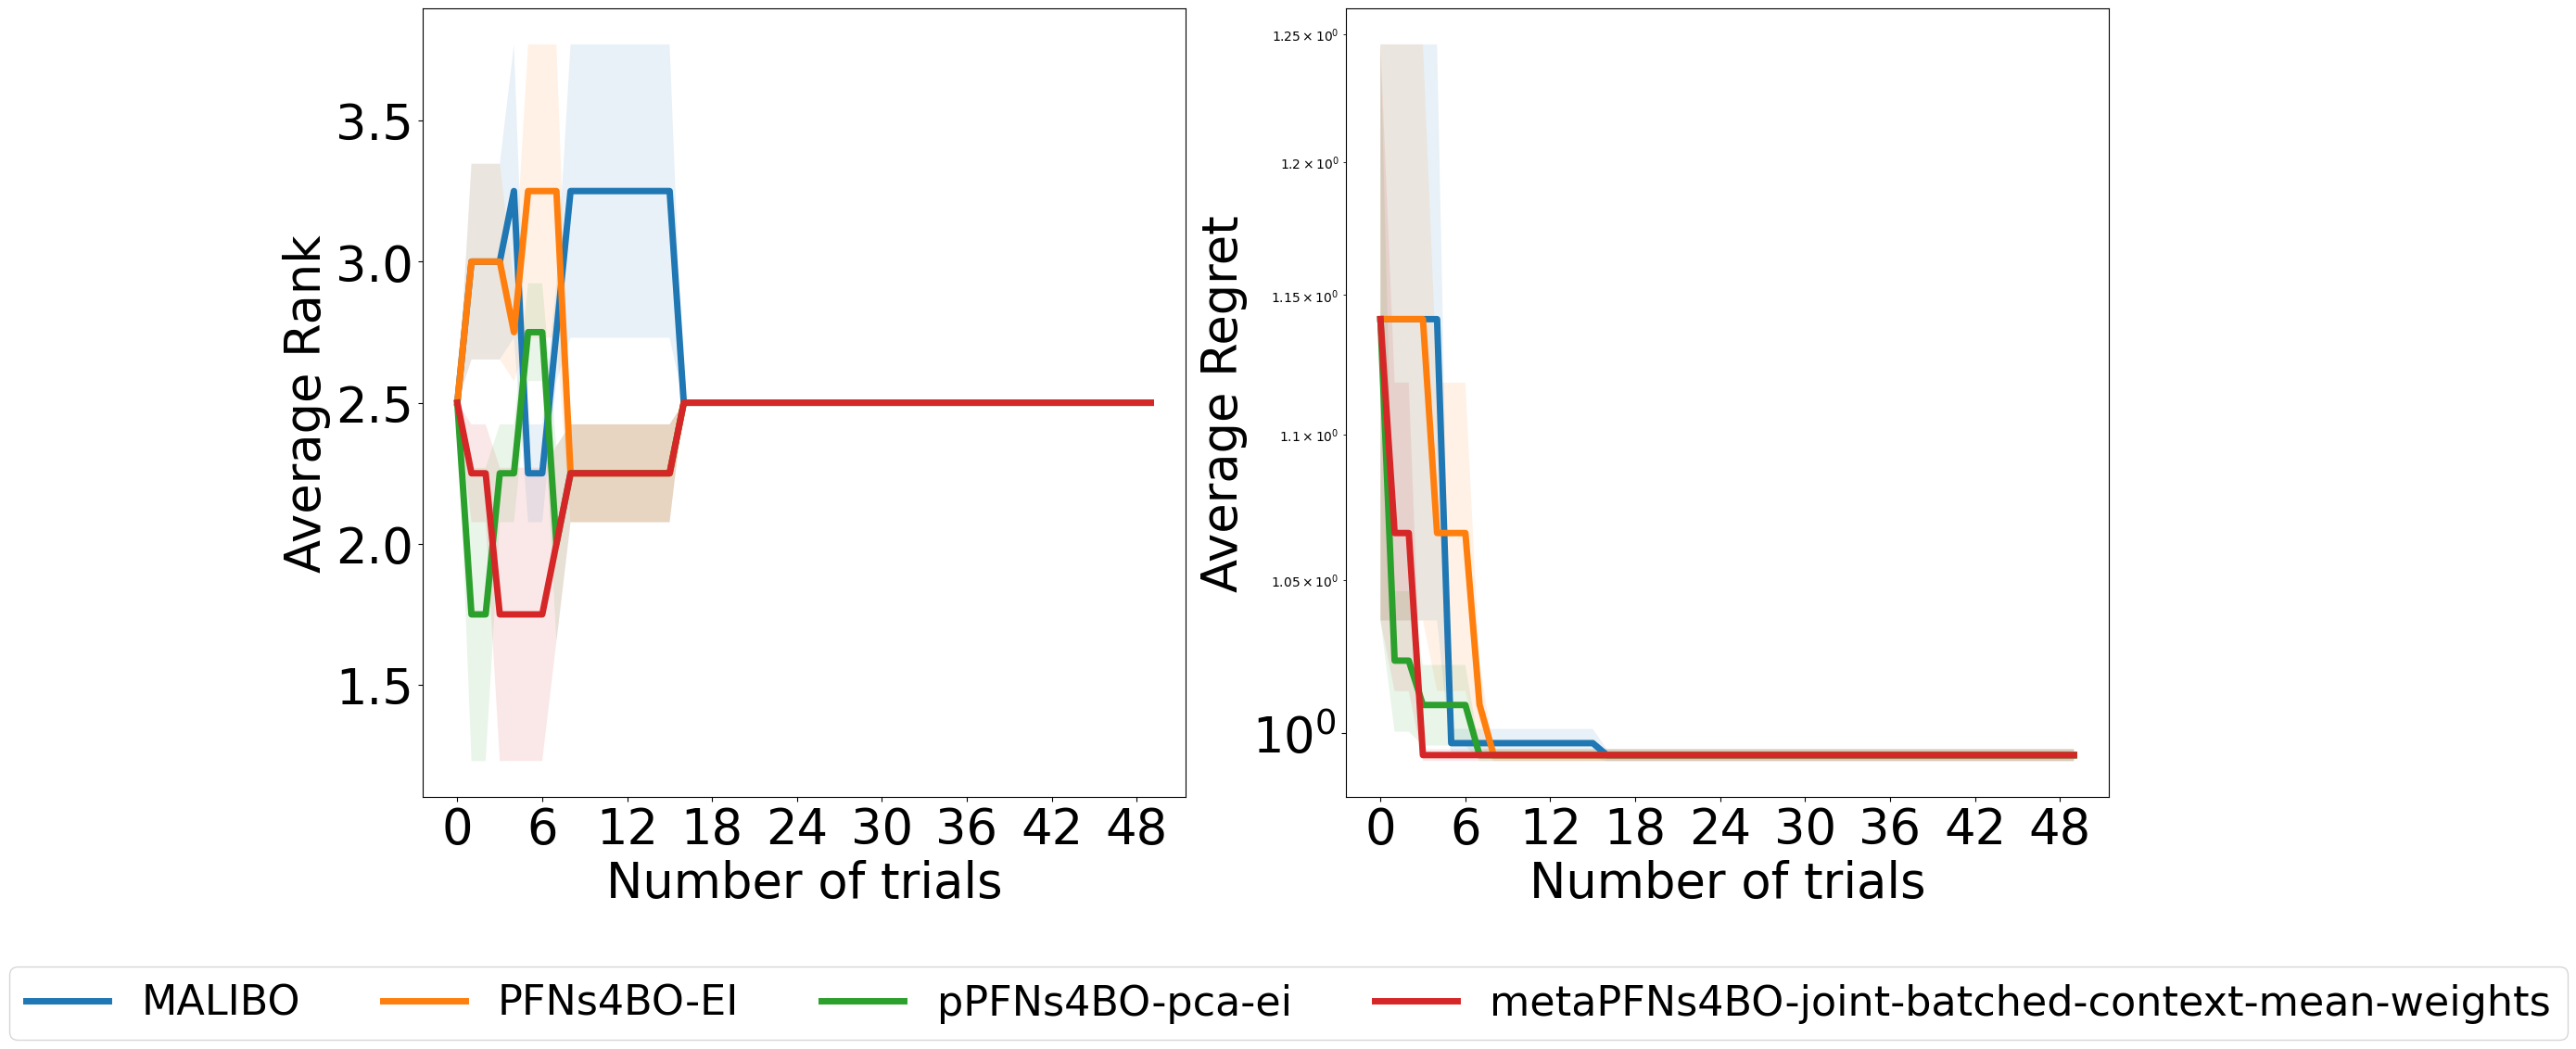

Finished


In [32]:
benchmark_plotter  = BenchmarkPlotter(experiments=algorithms, 
                                        results = results,
                                        seeds=seeds,
                                        spaces=spaces,
                                        task_list_per_space=task_list_per_space,
                                        time_horizon=time_horizon)

benchmark_plotter.plot()
# benchmark_plotter.draw_cd_diagram(bo_iter=25, name="Rank@25")
# benchmark_plotter.draw_cd_diagram(bo_iter=50, name="Rank@50")
# benchmark_plotter.draw_cd_diagram(bo_iter=100, name="Rank@100")

print("Finished")